# Logistic Regression: Training Vs. Test Data: Analysis of Credit Card Default   

In this program we will predit credit default based on some attributes. 
We will see how we can split the data  into Training and Test Sets

The model will be constructed based on Training Sample and performance of the model will be tested on Test Sample.

(In the prior program with the Default data our training data (used to build model) and test data (used to test model accuracy) were same)

The sample data is: Default.csv (10,000 observations)

We want to model whether individual is likely to default on credit card payment based on attributes such as - credit card balance, annual income, and student status (yes or no). 

In the sample data: 
default : 'Yes' implies individual defaulted on credit card payment, 'No' implies otherwise

default is a qualitative response variable, threfore classification model will be used to predit the liklelihood of default

The predictors (feature vectors) are as follows:

student : 'Yes' implies indiviual is a student, 'No' implies otehrwise : (qualitative predictor)

balance : credit card balance ($) of an individual (quantitative predictor)

income: annual income ($) of an individual (quantitative predictor)

References: 

book: An Introduction to Statistical Learning, with Application in R,  by James, Witten, Hastie, and Tibshirani
code: https://github.com/Mashimo/datascience/blob/master/01-Regression/LogisticRegressionSM.ipynb


# Import the Libraries

In [41]:
### Reference https://github.com/Mashimo/datascience/blob/master/01-Regression/LogisticRegressionSM.ipynb

import pandas as pd
import csv


import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as seabornInstance 
import statsmodels.api as sm

import statsmodels.formula.api as smf


from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn import metrics

# Part A: Upload the Default Data and Observe the Data

In [42]:
#read Default data
Default = pd.read_csv('H:\My Documents\TEACHING\Financial_Data_Analytics\MS_FINANCE_REVISED\DATA\Default.csv')

In [43]:
#view first 5 rows of the data
Default[:5]

,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879


In [44]:
#view first 5 rows of the data
Default.head()

,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879


In [45]:
#Checking the number of rows and columns
Default.shape

(10000, 5)

In [46]:
#Droppong column 0 as it is not needed and storing the data in a new object d2
d2=Default.drop(Default.columns[0], axis=1)
d2.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [47]:
#provide the summary stat of the quantitative variables
d2.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


# Part B : Construct Dummy Variables for Student and Default

CONSTRUCT DUMMY VARIABLES FOR THE CATEGORICAL VARIABLES STUDENT AND DEFAULT 

construct a dummy variable: student_dummy=1 if student=1; 0 otherwise     

construct a dummy varible: default_dummy=1 if default=1; 0 otherwise


In [48]:
#### The following code will replace student with the dummy variables #########
d3=pd.get_dummies(d2, columns=['student'])

d3.describe()

d3.head()

,default,balance,income,student_No,student_Yes
0,No,729.526495,44361.625074,1,0
1,No,817.180407,12106.134700,0,1
2,No,1073.549164,31767.138947,1,0
3,No,529.250605,35704.493935,1,0
4,No,785.655883,38463.495879,1,0


In [49]:
### WE want to keep the categorical variable and create a dummy variable for that in a seperate column ####

student_dummy=pd.get_dummies(d2['student'])

student_dummy.columns =['student_No', 'student_Yes'] 
student_dummy.head()

d3=pd.concat([d2,student_dummy], axis=1)
d3.head()


,default,student,balance,income,student_No,student_Yes
0,No,No,729.526495,44361.625074,1,0
1,No,Yes,817.180407,12106.134700,0,1
2,No,No,1073.549164,31767.138947,1,0
3,No,No,529.250605,35704.493935,1,0
4,No,No,785.655883,38463.495879,1,0


In [50]:
### creating dummy variable for default ######################################

default_dummy=pd.get_dummies(d2['default'])

default_dummy.columns =['default_No', 'default_Yes'] 
default_dummy.head()

d4=pd.concat([d3,default_dummy], axis=1)
d4.head()

,default,student,balance,income,student_No,student_Yes,default_No,default_Yes
0,No,No,729.526495,44361.625074,1,0,1,0
1,No,Yes,817.180407,12106.134700,0,1,1,0
2,No,No,1073.549164,31767.138947,1,0,1,0
3,No,No,529.250605,35704.493935,1,0,1,0
4,No,No,785.655883,38463.495879,1,0,1,0


In [51]:
## get the summary stat of the data
d4.describe()

,balance,income,student_No,student_Yes,default_No,default_Yes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,835.374886,33516.981876,0.705600,0.294400,0.966700,0.033300
std,483.714985,13336.639563,0.455795,0.455795,0.179428,0.179428
min,0.000000,771.967729,0.000000,0.000000,0.000000,0.000000
25%,481.731105,21340.462903,0.000000,0.000000,1.000000,0.000000
50%,823.636973,34552.644802,1.000000,0.000000,1.000000,0.000000
75%,1166.308386,43807.729272,1.000000,1.000000,1.000000,0.000000
max,2654.322576,73554.233495,1.000000,1.000000,1.000000,1.000000


# Part C : Split the Data into Training and Test Data

Reference: https://towardsdatascience.com/logistic-regression-python-7c451928efee


In [54]:

X = d4[['balance', 'income', 'student_Yes']].values
y = d4['default_Yes'].values.reshape(-1,1)

#Prior to training our model, we’ll set aside a portion of our data in order to evaluate its performance.

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=1)
X.shape

(10000, 3)

In [53]:
##See the size of the training sample
x_train.shape

(7500, 3)

In [33]:
##See the size of the test sample
x_test.shape

(2500, 3)

# Part D : Fit the Logistic Regression Model on the Training Data
Table 4.3 (JWHT): Fit a logistic regression to predict probability of default based on card balance, income, and student status 


In [55]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

print(lr.coef_)
print(lr.intercept_)

[[ 3.92573931e-04 -1.23033709e-04 -1.41694988e-06]]
[-1.11260924e-06]


C:\Users\rashraf\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


# Part: Use Predict() Function to estimate the default probability
predict() function: predicts the default probability for an individual on the basis of the predicted model.


In [56]:
## Let’s see how the model performs against data that it hasn’t been trained on, that is test data.
## For the following predict() : there is no obs assigned as y_pred=1 based on probabilities, as it uses prob>0.5 as cut off. 
## Calibrate first computing the prob and then assigning 1 or 0 using a chosen cut-off value
y_pred = lr.predict(x_test)
y_pred.mean()

0.0

In [57]:
confusion_matrix(y_test, y_pred)

array([[2421,    0],
       [  79,    0]], dtype=int64)

In [58]:
# TO check the actual probability that a data point belongs to a given class, we can use the function predict_proba() 
#The first column corresponds to the probability that the sample belongs to the first class (0) and the 
#second column corresponds to the probability that the sample belongs to the second class (1).
print(lr.predict_proba(x_test))
#y_pred.head()

[[0.80936474 0.19063526]
 [0.9973496  0.0026504 ]
 [0.97880868 0.02119132]
 ...
 [0.98930714 0.01069286]
 [0.97316135 0.02683865]
 [0.99762955 0.00237045]]


In [38]:
# TO check the actual probability that a data point belongs to a given class, we can use the function predict_proba() 
#The first column corresponds to the probability that the sample belongs to the first class and the second column corresponds to the probability that the sample belongs to the second class.

y_pred=lr.predict_proba(x_test)[:,1]  #take the second column 

# y_pred is numpy.ndarray. Convert it to pandas.core.series.Series to use the apply function to assign type 1/0 based on probabilities
y_pred_series = pd.Series(y_pred)
y_pred_series.head()
y_pred_series.describe()

type(y_pred_series)

y_pred2 = y_pred_series.apply(lambda r: 1 if r > 0.1 else 0)
y_pred2.head()


y_pred2.describe()
type(y_pred2)
y_pred3 = y_pred2.values.reshape(-1,1)  # change to array 

In [59]:
# Use  confusion matrix to measure the accuracy of our model.

confusion_matrix(y_test, y_pred3)      



array([[1858,  563],
       [  44,   35]], dtype=int64)

In [60]:
accuracy = np.mean(y_pred3 == y_test)
print ('accuracy = {0}%'.format(accuracy*100)  )


accuracy = 75.72%


# Part F : Overall Analysis

On the test sample of total 2500 observations:

Overall Accuracy=(1858+35)/2500=75.72%: reasonable accuracy

TPR (recall) = 35/(35+44) = 44.30%:

out of all actual default cases only 44.3% were predicted right (as default category) by the model Therefore the model is identifying a bad client (default category) as good (non-default category) 44/79=55.7% of the time. Conversely, 55.7% of the actual default cetegory were indentified as non-default category by the model. Credit card company which is trying to identify high risk individuals: an error rate of 55.7% would be unacceptable

Precision=35/(35+563)=5.85%

Out of 598 predicted to be positive (default category), only 5.85% are actually true. (very low). Therefore, 94.15% of the time model predicted default category are wrongly classified.  


F-measure = 2X0.4430X0.0585/(0.443+0.0585)= 10.33%

Specificity or True Negative Rate (TNR)=1858/(1858+563)=76.75%

76.75% of actual false cases (non-default category) was identified correctly as non-default. Model is able to identify good customers only 76.75% of the time. 

FPR=1-Specificity=563/(1858+563)=23.25% Pretty high FPR. 563 out of 2421 individuals who did not actually default were incorrectly labeled as default category (false positive rate). Pretty high rejection rate of good customers 

From the perspective of a credit card company that is trying to identify high-risk individuals, an error rate (1-TPR) or false negative of 44/79 = 55.7% among individuals who defaulted may well be unacceptable. Addionally error rate (FPR) of 23.25% with false positive is quite high. 

Need to see how the model performs with different threshold. 


In [81]:
# TO check the actual probability that a data point belongs to a given class, we can use the function predict_proba() 
#The first column corresponds to the probability that the sample belongs to the first class and the second column corresponds to the probability that the sample belongs to the second class.

y_pred=lr.predict_proba(x_test)[:,1]  #take the second column 

# y_pred is numpy.ndarray. Convert it to pandas.core.series.Series to use the apply function to assign type 1/0 based on probabilities
y_pred_series = pd.Series(y_pred)
y_pred_series.head()
y_pred_series.describe()

type(y_pred_series)

y_pred2 = y_pred_series.apply(lambda r: 1 if r > 0.15 else 0)
y_pred2.head()


y_pred2.describe()
type(y_pred2)
y_pred3 = y_pred2.values.reshape(-1,1)  # change to array 
confusion_matrix(y_test, y_pred3)  

array([[2097,  324],
       [  51,   28]], dtype=int64)

# Part F : Analysis with Threshold 0.15

On the test sample of total 2500 observations:

Logistic Model predicted: 352 would default: 28 actually defaulted and 324 did not

Overall correct predictions = (2097+28)/2500 = 85% 
Overall errror rate = 15%

False positive = 324/2421 = 13.38% (actual did-not deault, model prediced to be deault category)
False negative = 51/79 = 64.55% (actual defaulted, but model predicted to be not-default category)

In this thershold, the overall error rate improves however the %FN increased. 
From the perspective of a credit card company that is trying to identify high-risk individuals, an error rate of 64.55% among individuals who defaulted may well be unacceptable. 


# Part H : Understanding AUC - ROC Curve

Code SOURCE: https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/

Reading Source: https://towardsdatascience.com/understanding-auc-roc-curve-68b2303cc9c5


Logistic: ROC AUC=0.605


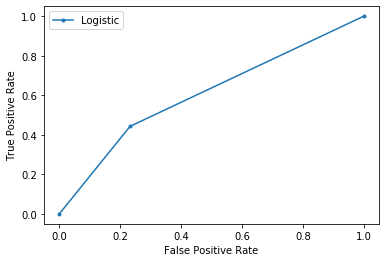

In [61]:
##########################################################################################
##### Understanding AUC - ROC Curve

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
# calculate scores

lr_auc = roc_auc_score(y_test, y_pred3)
# summarize scores

print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves


lr_fpr, lr_tpr, thresholds = roc_curve(y_test,  y_pred3)
# plot the roc curve for the model

pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()